<a href="https://colab.research.google.com/github/petricksoares/simula-o-de-monte-carlo/blob/main/C%C3%B3pia_de_Atividade_2_Simula%C3%A7%C3%A3o_de_Monte_Carlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Simulação de Monte Carlo - Caso TechToy**
1. **Introdução e Contexto**

A empresa TechToy está prestes a lançar um novo drone no mercado. A diretoria está em dúvida entre duas estratégias de lançamento e contratou você, analista de dados, para realizar uma Simulação de Monte Carlo.

O objetivo é entender não apenas o lucro esperado, mas o risco de prejuízo de cada decisão.

As Estratégias:
Estratégia A (Conservadora): Foca em um público de nicho, com preço mais alto e vendas mais previsíveis.

Estratégia B (Agressiva): Foca em escala, com preço menor, mas com custos de produção e volume de vendas muito mais incertos.

**2. Base de Dados e Parâmetros**

Execute a célula abaixo para carregar as bibliotecas necessárias e os parâmetros oficiais fornecidos pelo departamento financeiro.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Configurações da Simulação
N_SIMULACOES = 10000

# --- PARÂMETROS ESTRATÉGIA A ---
vendas_media_a = 500
vendas_desvio_a = 50
custo_min_a = 600
custo_max_a = 700
preco_venda_a = 1200
investimento_fixo_a = 50000

# --- PARÂMETROS ESTRATÉGIA B ---
vendas_media_b = 800
vendas_desvio_b = 250
custo_min_b = 400
custo_max_b = 800
preco_venda_b = 1000
investimento_fixo_b = 150000

print("Parâmetros carregados com sucesso!")

Parâmetros carregados com sucesso!


3. Desafio

**1: Modelagem do Lucro**

Crie uma função ou um script que utilize os parâmetros acima para gerar 10.000 resultados possíveis de lucro para cada estratégia.Dicas:Para as Vendas, use uma distribuição Normal: np.random.normal(media, desvio, N_SIMULACOES).Para o Custo Unitário, use uma distribuição Uniforme: np.random.uniform(min, max, N_SIMULACOES).

A fórmula do lucro é:

$Lucro = (Vendas \times Preço) - (Vendas \times Custo\_Unitário) - Investimento\_Fixo$

In [3]:
N_SIMULACOES = 10000

# Função de simulação
def simular_lucro(vendas_media, vendas_desvio, custo_min, custo_max, preco_venda, investimento_fixo):

    vendas = np.random.normal(vendas_media, vendas_desvio, N_SIMULACOES)
    custo_unitario = np.random.uniform(custo_min, custo_max, N_SIMULACOES)

    lucro = (vendas * preco_venda) - (vendas * custo_unitario) - investimento_fixo

    return lucro

# Função de análise
def analisar_resultados(nome, lucro):

    lucro_medio = np.mean(lucro)
    desvio_padrao = np.std(lucro)
    prob_prejuizo = np.mean(lucro < 0) * 100

    print(f"\n{nome}")
    print(f"Lucro médio: R$ {lucro_medio:.2f}")
    print(f"Desvio padrão: R$ {desvio_padrao:.2f}")
    print(f"Probabilidade de prejuízo: {prob_prejuizo:.2f}%")
    print(f"Pior cenário: R$ {np.min(lucro):.2f}")
    print(f"Melhor cenário: R$ {np.max(lucro):.2f}")

# Estratégia A
lucro_a = simular_lucro(500, 50, 600, 700, 1200, 50000)

# Estratégia B
lucro_b = simular_lucro(800, 250, 400, 800, 1000, 150000)

# Exibindo resultados
analisar_resultados("Estratégia A", lucro_a)
analisar_resultados("Estratégia B", lucro_b)


Estratégia A
Lucro médio: R$ 224898.47
Desvio padrão: R$ 31357.77
Probabilidade de prejuízo: 0.00%
Pior cenário: R$ 125216.57
Melhor cenário: R$ 336133.41

Estratégia B
Lucro médio: R$ 169226.31
Desvio padrão: R$ 138209.59
Probabilidade de prejuízo: 8.78%
Pior cenário: R$ -182747.56
Melhor cenário: R$ 789840.02


**2: Visualização dos Resultados**

Gere um histograma comparando as duas estratégias. O gráfico deve ajudar a diretoria a visualizar onde o lucro se concentra e onde estão os riscos de perda (valores abaixo de zero).

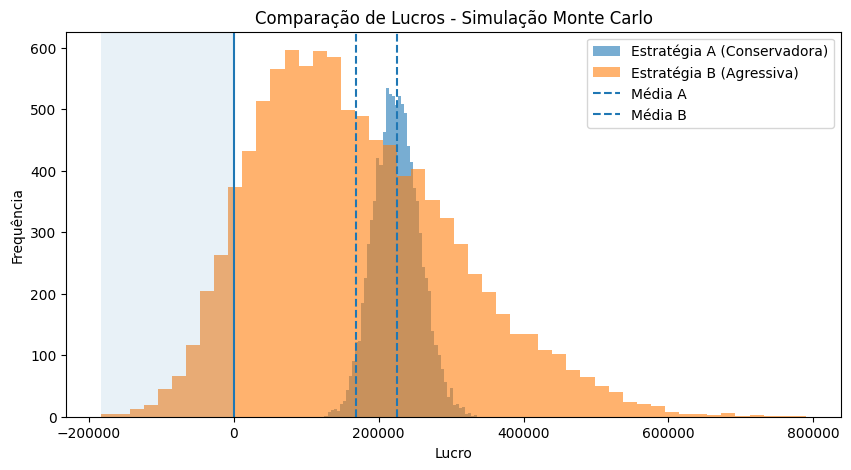

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(lucro_a, bins=50, alpha=0.6, label="Estratégia A (Conservadora)")
plt.hist(lucro_b, bins=50, alpha=0.6, label="Estratégia B (Agressiva)")
plt.axvline(0)
plt.axvspan(min(lucro_b), 0, alpha=0.1)

# Linhas de média
plt.axvline(np.mean(lucro_a), linestyle='--', label="Média A")
plt.axvline(np.mean(lucro_b), linestyle='--', label="Média B")

# Títulos
plt.title("Comparação de Lucros - Simulação Monte Carlo")
plt.xlabel("Lucro")
plt.ylabel("Frequência")
plt.legend()
plt.show()

**3: Cálculo de Probabilidades**
Calcule e exiba as seguintes métricas para cada estratégia:

Média de Lucro.

Probabilidade de Prejuízo (porcentagem de simulações onde o lucro foi < 0).

In [7]:
# Função de cálculo das métricas
def calcular_metricas(nome, lucro):

    media_lucro = np.mean(lucro)
    prob_prejuizo = np.mean(lucro < 0) * 100

    print(f"\n{nome}")
    print(f"Média de Lucro: R$ {media_lucro:.2f}")
    print(f"Probabilidade de Prejuízo: {prob_prejuizo:.2f}%")

# Aplicando para cada estratégia
calcular_metricas("Estratégia A", lucro_a)
calcular_metricas("Estratégia B", lucro_b)


Estratégia A
Média de Lucro: R$ 224898.47
Probabilidade de Prejuízo: 0.00%

Estratégia B
Média de Lucro: R$ 169226.31
Probabilidade de Prejuízo: 8.78%
